# Fase 3 - Modelado & Evaluación

Igual que el 02: la lógica está en `src/` (`model.py`, `evaluate.py`) y aquí la usamos y la
contamos. Tres bloques:
1. Comparar tres modelos y elegir el mejor por PR-AUC.
2. Ponerlo en contexto: baseline tonto y validación cruzada (¿es estable?).
3. Elegir el umbral por coste en euros, que es la decisión que de verdad importa en fraude.

In [1]:
# Permite ejecutar el notebook desde cualquier carpeta (p.ej. con jupyter nbconvert):
# subimos hasta la raiz del proyecto y la anadimos al path para poder importar src/.
import sys
from pathlib import Path
_root = Path.cwd()
while not (_root / "config.yaml").exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pickle
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

from src.config import load_config, path
from src import model as M
from src.evaluate import (dummy_baseline, cross_val_prauc, threshold_cost_curve,
                          reconstruct_amount, business_impact, classification_metrics)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "axes.titleweight": "bold"})
cfg = load_config()
REPORTS = path(cfg["paths"]["reports"])

splits = pickle.load(open(path(cfg["data"]["splits"]), "rb"))
out = M.train_and_select(splits, cfg)
best = out["best"]
y_test = out["y_test"]
proba = out["probas"][best]
print("Mejor modelo (por PR-AUC):", best)
pd.DataFrame(out["results"]).T.round(4)

Mejor modelo (por PR-AUC): XGBoost


,roc_auc,pr_auc,f1,precision,recall
Logistic Regression,0.9589,0.6801,0.0942,0.0498,0.8526
Random Forest,0.9386,0.8172,0.8295,0.9012,0.7684
XGBoost,0.9740,0.8186,0.7772,0.7653,0.7895


## Comparación de modelos y curvas ROC

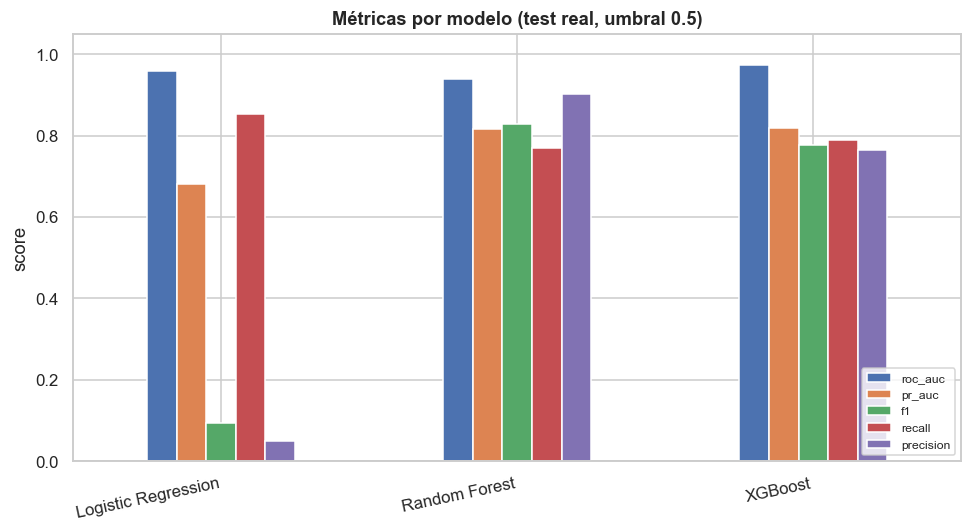

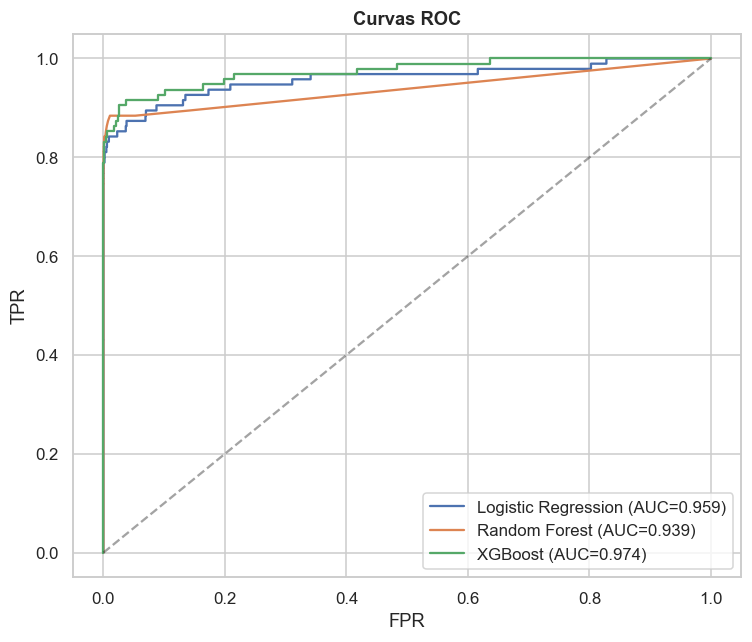

In [2]:
tab = pd.DataFrame(out["results"]).T

fig, ax = plt.subplots(figsize=(9, 5))
tab[["roc_auc", "pr_auc", "f1", "recall", "precision"]].plot.bar(ax=ax)
ax.set_title("Métricas por modelo (test real, umbral 0.5)")
ax.set_ylabel("score"); ax.set_ylim(0, 1.05)
ax.set_xticklabels(tab.index, rotation=12, ha="right"); ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(REPORTS / "06_model_comparison.png", bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
for name in out["results"]:
    fpr, tpr, _ = roc_curve(y_test, out["probas"][name])
    ax.plot(fpr, tpr, label=f"{name} (AUC={out['results'][name]['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_title("Curvas ROC"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(loc="lower right")
fig.tight_layout(); fig.savefig(REPORTS / "07_roc_curves.png", bbox_inches="tight"); plt.show()

## ¿El modelo aporta algo? Baseline y validación cruzada

Un baseline tonto (predecir siempre 'legítima') marca el suelo. Y la validación cruzada nos dice si la PR-AUC es estable o fue suerte de un split.

In [3]:
baseline = dummy_baseline(splits["X_train_raw"], splits["y_train_raw"], splits["X_test"], y_test)
cv_mean, cv_std = cross_val_prauc(out["fitted"][best], splits["X_train_raw"],
                                  splits["y_train_raw"], cfg["seed"])
print(f"Baseline tonto      -> PR-AUC {baseline['pr_auc']:.4f}, recall {baseline['recall']:.3f}")
print(f"{best} (1 split)     -> PR-AUC {out['results'][best]['pr_auc']:.4f}")
print(f"{best} (CV 5-fold)   -> PR-AUC {cv_mean:.4f} ± {cv_std:.4f}")

Baseline tonto      -> PR-AUC 0.0017, recall 0.000
XGBoost (1 split)     -> PR-AUC 0.8186
XGBoost (CV 5-fold)   -> PR-AUC 0.8430 ± 0.0312


## Análisis del mejor modelo (umbral 0.5)

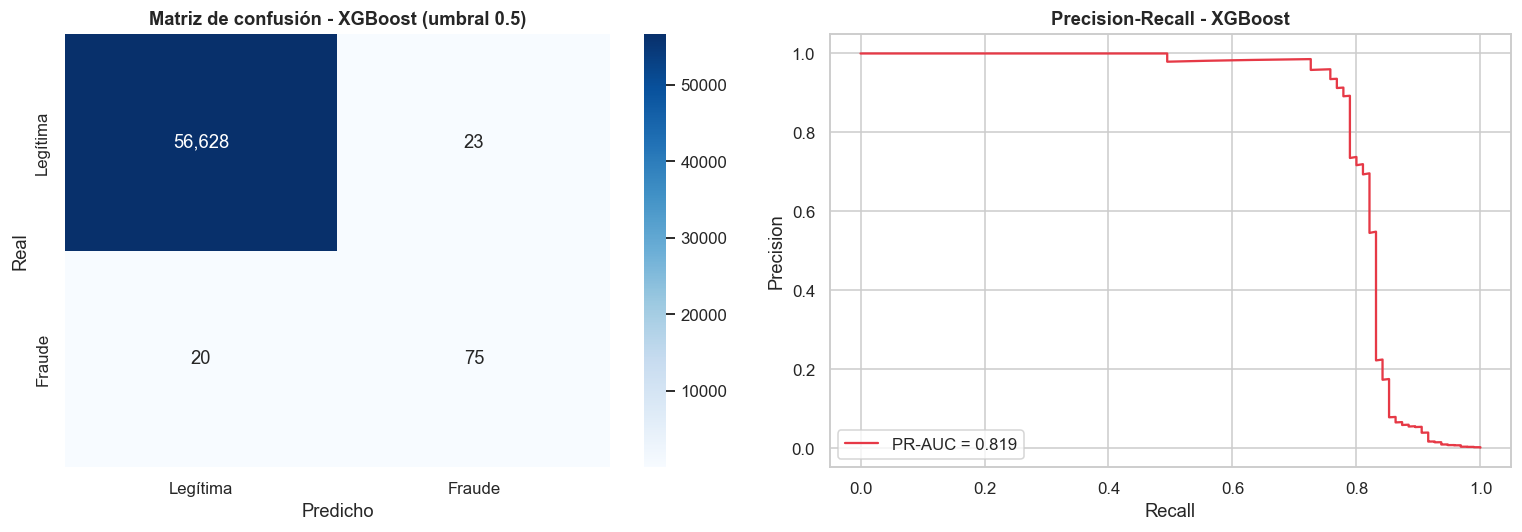

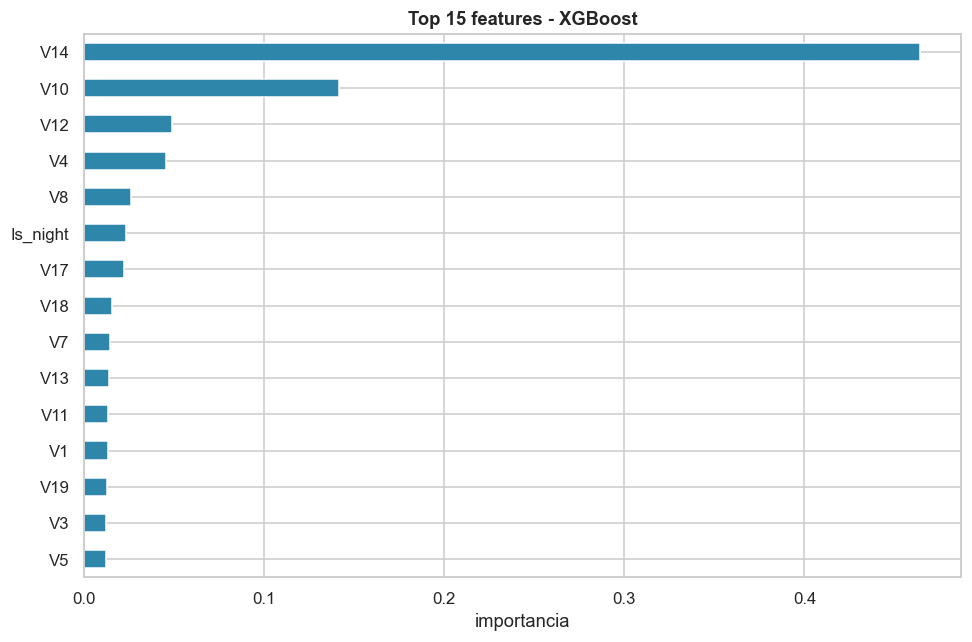

In [4]:
pred05 = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred05)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=axes[0],
            xticklabels=["Legítima", "Fraude"], yticklabels=["Legítima", "Fraude"])
axes[0].set_title(f"Matriz de confusión - {best} (umbral 0.5)")
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")
pr, rc, _ = precision_recall_curve(y_test, proba)
axes[1].plot(rc, pr, color="#E63946", label=f"PR-AUC = {out['results'][best]['pr_auc']:.3f}")
axes[1].set_title(f"Precision-Recall - {best}"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend()
fig.tight_layout(); fig.savefig(REPORTS / "08_best_model.png", bbox_inches="tight"); plt.show()

imp = pd.Series(out["fitted"][best].feature_importances_, index=splits["features"]).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 6)); imp[::-1].plot.barh(ax=ax, color="#2E86AB")
ax.set_title(f"Top 15 features - {best}"); ax.set_xlabel("importancia")
fig.tight_layout(); fig.savefig(REPORTS / "09_feature_importance.png", bbox_inches="tight"); plt.show()

## El umbral que importa: minimizar el coste en euros

El 0.5 no es sagrado. En fraude, dejar pasar un fraude (FN) cuesta el monto real de esa
transacción; una falsa alarma (FP) cuesta lo que vale revisarla a mano. Buscamos el umbral que
minimiza la suma de ambos.

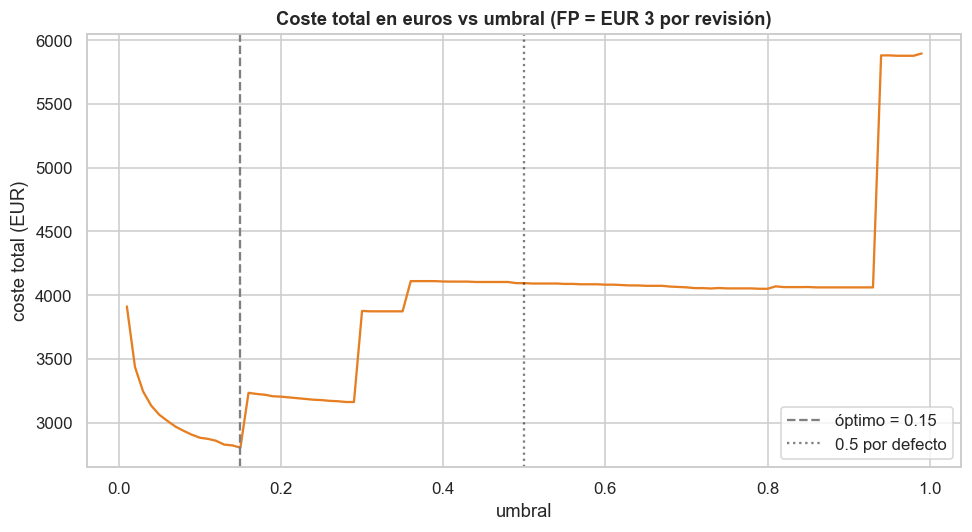

Umbral 0.5 (por defecto): recall 0.789, 75/95 fraudes, 23 falsas alarmas, coste EUR 4,094
Umbral 0.15 (óptimo por coste): recall 0.832, 79/95 fraudes, 65 falsas alarmas, coste EUR 2,803


In [5]:
amount = reconstruct_amount(splits["X_test"], splits["scaler"], splits["cols_scaled"], splits["features"])
fp_cost = cfg["costs"]["fp_review_cost"]
ths, costs, t_star, cost_star = threshold_cost_curve(y_test, proba, amount, fp_cost)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ths, costs, color="#E67E22")
ax.axvline(t_star, ls="--", color="gray", label=f"óptimo = {t_star:.2f}")
ax.axvline(0.5, ls=":", color="black", alpha=.5, label="0.5 por defecto")
ax.set_title(f"Coste total en euros vs umbral (FP = EUR {fp_cost:.0f} por revisión)")
ax.set_xlabel("umbral"); ax.set_ylabel("coste total (EUR)"); ax.legend()
fig.tight_layout(); fig.savefig(REPORTS / "11_threshold_cost.png", bbox_inches="tight"); plt.show()

for t, etiqueta in [(0.5, "0.5 (por defecto)"), (t_star, f"{t_star:.2f} (óptimo por coste)")]:
    pred = (proba >= t).astype(int)
    imp_b = business_impact(y_test, pred, amount)
    m = classification_metrics(y_test, proba, t)
    coste = imp_b["losses_missed_eur"] + fp_cost * imp_b["fp"]
    print(f"Umbral {etiqueta}: recall {m['recall']:.3f}, "
          f"{imp_b['tp']}/{imp_b['frauds_total']} fraudes, {imp_b['fp']} falsas alarmas, "
          f"coste EUR {coste:,.0f}")

## Conclusión

Bajar el umbral a su punto óptimo por coste detecta más fraude (sube el recall) a cambio de más
falsas alarmas, pero el coste total en euros baja: es la decisión correcta de negocio. Ese umbral
queda guardado en `src/best_model.pkl` para que el dashboard y la API usen el mismo punto de
operación. Las métricas completas están en `reports/metrics.json`.